# RIPL Exercise Worksheet
Adapted from Maniskill quickstart (https://colab.research.google.com/github/haosulab/ManiSkill/blob/main/examples/tutorials/1_quickstart.ipynb)

# Setup Code

To begin, prepare the colab environment by switching to a GPU environment (Runtime -> Change Runtime Type)

Then click the play button below. This will install all dependencies for the future code. ManiSkill only requires two pip packages (`maniskill` and `torch`) and setting up Vulkan. For those setting up their code locally you can check our [installation docs](https://maniskill.readthedocs.io/en/latest/user_guide/getting_started/installation.html)

In [1]:
# setup vulkan
!mkdir -p /usr/share/vulkan/icd.d
!wget -q https://raw.githubusercontent.com/haosulab/ManiSkill/main/docker/nvidia_icd.json
!wget -q https://raw.githubusercontent.com/haosulab/ManiSkill/main/docker/10_nvidia.json
!mv nvidia_icd.json /usr/share/vulkan/icd.d
!mv 10_nvidia.json /usr/share/glvnd/egl_vendor.d/10_nvidia.json
!apt-get install -y --no-install-recommends libvulkan-dev
# dependencies
!pip install --upgrade mani_skill tyro

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libvulkan1
Recommended packages:
  mesa-vulkan-drivers | vulkan-icd
The following NEW packages will be installed:
  libvulkan-dev libvulkan1
0 upgraded, 2 newly installed, 0 to remove and 34 not upgraded.
Need to get 1,020 kB of archives.
After this operation, 17.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libvulkan1 amd64 1.3.204.1-2 [128 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libvulkan-dev amd64 1.3.204.1-2 [892 kB]
Fetched 1,020 kB in 2s (430 kB/s)
Selecting previously unselected package libvulkan1:amd64.
(Reading database ... 126101 files and directories currently installed.)
Preparing to unpack .../libvulkan1_1.3.204.1-2_amd64.deb ...
Unpacking libvulkan1:amd64 (1.3.204.1-2) ...
Selecting previously unselected package libvulkan-dev:amd64.
Preparing to unpa

In [2]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    import site
    site.main() # run this so local pip installs are recognized

# T-I Getting Setup with Maniskill

I setup my own fork of the repository which can be found at:

In [41]:
!git clone https://github.com/Blizzard42/ManiSkill.git --recurse-submodules

Cloning into 'ManiSkill'...
remote: Enumerating objects: 8646, done.
remote: Counting objects: 100% (351/351), done.
remote: Compressing objects: 100% (230/230), done.
remote: Total 8646 (delta 218), reused 153 (delta 121), pack-reused 8295 (from 3)
Receiving objects: 100% (8646/8646), 466.07 MiB | 16.26 MiB/s, done.
Resolving deltas: 100% (4597/4597), done.
Updating files: 100% (1426/1426), done.
Submodule 'examples/baselines/diffusion_policy/V-GPS' (https://github.com/Blizzard42/V-GPS.git) registered for path 'examples/baselines/diffusion_policy/V-GPS'
Cloning into '/content/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/V-GPS'...
remote: Enumerating objects: 66, done.        
remote: Counting objects: 100% (66/66), done.        
remote: Compressing objects: 100% (61/61), done.        
remote: Total 66 (delta 8), reused 58 (delta 4), pack-reused 0 (

Due to some initial trouble with needing to recover my github account, I started on a clone of the original repository and transfered my work to the fork when I finished recovering my github. This is just one example of the technical problem solving I employed while working through this assessment.

The environment can be set up by running:

In [42]:
%cd ManiSkill/examples/baselines/diffusion_policy/
!pip install -e .

/content/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy
Obtaining file:///content/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy
  Preparing metadata (setup.py) ... done
  Attempting uninstall: diffusion_policy
    Found existing installation: diffusion_policy 0.1.0
    Uninstalling diffusion_policy-0.1.0:
      Successfully uninstalled diffusion_policy-0.1.0
  Running setup.py develop for diffusion_policy


This concludes the first task.

# T-II: Diffusion Policy on RGB PushT-v1 with End Effector Delta Pose

We can install the data by using the provided data downloading script

In [32]:
# Install PushT-v1 raw demos
!python -m mani_skill.utils.download_demo "PushT-v1"

35.7Mit [00:00, 88.9Mit/s]              


We can then replay the demos to get the rest of the demo information because not all of it is included out of the box. Because the task description said 'visual-input based', we use rgb output.

In [33]:
# Replay demos to collect rgb data
!python -m mani_skill.trajectory.replay_trajectory \
  --traj-path ~/.maniskill/demos/PushT-v1/rl/trajectory.none.pd_ee_delta_pos.physx_cuda.h5 \
  --use-env-states -c pd_ee_delta_pos -o rgb \
  --save-traj --num-envs 256 -b physx_cuda

^C


The above command took ~5:28 for RGB data after restarting session, but had an ETA of 10-25 hours before restart.

Note that for some reason, only 799 of the 888 demos are saved. I have recreated this across multiple environments and it seems to consistently only be able to save 799. I'm not sure why yet.

Login to wandb:

In [ ]:
!wandb login [Your API Key Here]

wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


The above is a workaround to get wandb working because other methods didn't work (possibly due to my combination of firefox + ubuntu linux)

In [ ]:
# Train RGB
!python train_rgbd.py --env-id PushT-v1 \
    --demo-path ~/.maniskill/demos/PushT-v1/rl/trajectory.rgb.pd_ee_delta_pos.physx_cuda.h5 \
    --control-mode "pd_ee_delta_pos" --sim-backend "physx_cuda" --num-demos 799 --max_episode_steps 100 \
    --total_iters 50000 --act_horizon 4 --obs-mode "rgb" --seed 123 \
    --exp-name diffusion_policy-PushT-v1-rgb-799_rl_demos-123-attempt1 \
    --demo_type=rl --track

2025-04-25 17:52:58.531320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745603578.790654   24157 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745603578.879641   24157 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-25 17:52:59.527887: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Current

I did some testing with the number of envs usable above. While on the state version of the enviornment, it's easy to get ~100 enviornments running, for RGB it seems the best you can do is around 10 (the default if the parameter is not set for train_rgbd). The above takes about 4 hours to run, which is just too slow. My laptop GPU (RTX 4060) is able to run faster, but runs into a memory limit with the RGB version of the enviornment. I was able to get this running on PACE, but even then its performance was very low. Because of this, for the remainder of the assignment, we will simply use the state version.

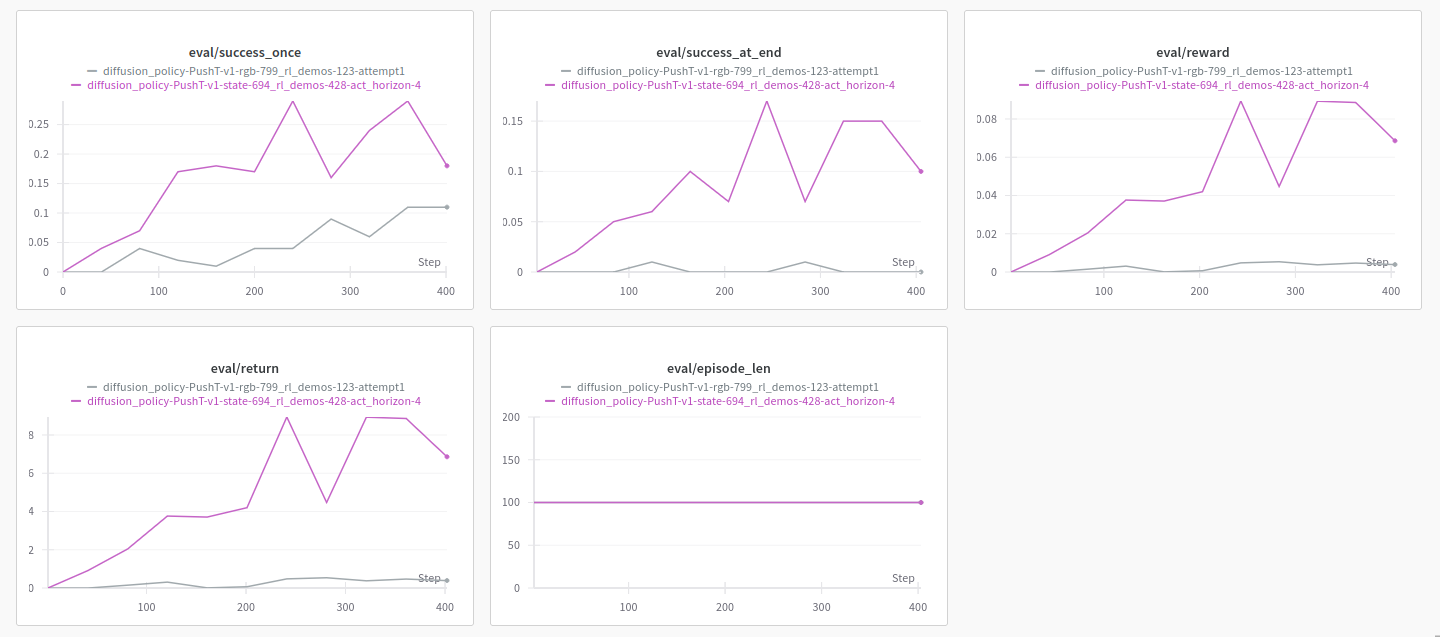

In [5]:
# Visualize MY performance of RGB vs State (not referencing this notebook) Your performance can be found on wandb
from IPython.display import Image
Image("./media/PushTStateVsRGB.png")

In [34]:
# Replay demos to collect state data
!python -m mani_skill.trajectory.replay_trajectory \
  --traj-path ~/.maniskill/demos/PushT-v1/rl/trajectory.none.pd_ee_delta_pose.physx_cuda.h5 \
  --use-env-states -c pd_ee_delta_pose -o state \
  --save-traj --num-envs 1024 -b physx_cuda

0step [00:00, ?step/s]Downloading PhysX GPU library to /root/.sapien/physx/105.1-physx-5.3.1.patch0 from Github. This can take several minutes. If it fails to download, please manually download fhttps://github.com/sapien-sim/physx-precompiled/releases/download/105.1-physx-5.3.1.patch0/linux-so.zip and unzip at /root/.sapien/physx/105.1-physx-5.3.1.patch0.
Download complete.
2025-04-30 20:00:14,263 - mani_skill  - WARNING - mani_skill is not installed with git.
100% 719/719 [02:00<00:00,  5.94step/s] 
  0% 0/719 [02:13<?, ?step/s]
Replayed 719 episodes, 694/719=96.52% demos saved


In [ ]:
!python train.py --env-id PushT-v1 \
    --demo-path ~/.maniskill/demos/PushT-v1/rl/trajectory.state.pd_ee_delta_pose.physx_cuda.h5 \
    --control-mode "pd_ee_delta_pose" --sim-backend "physx_cuda" --num-demos 694 --max_episode_steps 100 --num_eval_envs 100 \
    --total_iters 50000 --act_horizon 1 --seed 1 \
    --exp-name diffusion_policy-PushT-v1-state-694_rl_demos-1-act_horizon-1 --no_capture_video \
    --demo_type=rl --track

In [ ]:
!python train.py --env-id PushT-v1 \
    --demo-path ~/.maniskill/demos/PushT-v1/rl/trajectory.state.pd_ee_delta_pose.physx_cuda.h5 \
    --control-mode "pd_ee_delta_pose" --sim-backend "physx_cuda" --num-demos 694 --max_episode_steps 100 --num_eval_envs 100 \
    --total_iters 50000 --act_horizon 2 --seed 123 \
    --exp-name diffusion_policy-PushT-v1-state-694_rl_demos-123-act_horizon-2 --no_capture_video \
    --demo_type=rl --track

In [ ]:
!python train.py --env-id PushT-v1 \
    --demo-path ~/.maniskill/demos/PushT-v1/rl/trajectory.state.pd_ee_delta_pose.physx_cuda.h5 \
    --control-mode "pd_ee_delta_pose" --sim-backend "physx_cuda" --num-demos 694 --max_episode_steps 100 --num_eval_envs 100 \
    --total_iters 50000 --act_horizon 4 --seed 428 \
    --exp-name diffusion_policy-PushT-v1-state-694_rl_demos-428-act_horizon-4 --no_capture_video \
    --demo_type=rl --track

In [ ]:
!python train.py --env-id PushT-v1 \
    --demo-path ~/.maniskill/demos/PushT-v1/rl/trajectory.state.pd_ee_delta_pose.physx_cuda.h5 \
    --control-mode "pd_ee_delta_pose" --sim-backend "physx_cuda" --num-demos 694 --max_episode_steps 100 --num_eval_envs 100 \
    --total_iters 50000 --act_horizon 8 --seed 187 \
    --exp-name diffusion_policy-PushT-v1-state-694_rl_demos-187-act_horizon-8 --no_capture_video \
    --demo_type=rl --track

python3: can't open file '/content/train.py': [Errno 2] No such file or directory


In [ ]:
!python train.py --env-id PushT-v1 \
    --demo-path ~/.maniskill/demos/PushT-v1/rl/trajectory.state.pd_ee_delta_pose.physx_cuda.h5 \
    --control-mode "pd_ee_delta_pose" --sim-backend "physx_cuda" --num-demos 694 --max_episode_steps 100 --num_eval_envs 100 \
    --total_iters 50000 --act_horizon 16 --seed 474 \
    --exp-name diffusion_policy-PushT-v1-state-694_rl_demos-474-act_horizon-16 --no_capture_video \
    --demo_type=rl --track

python3: can't open file '/content/train.py': [Errno 2] No such file or directory


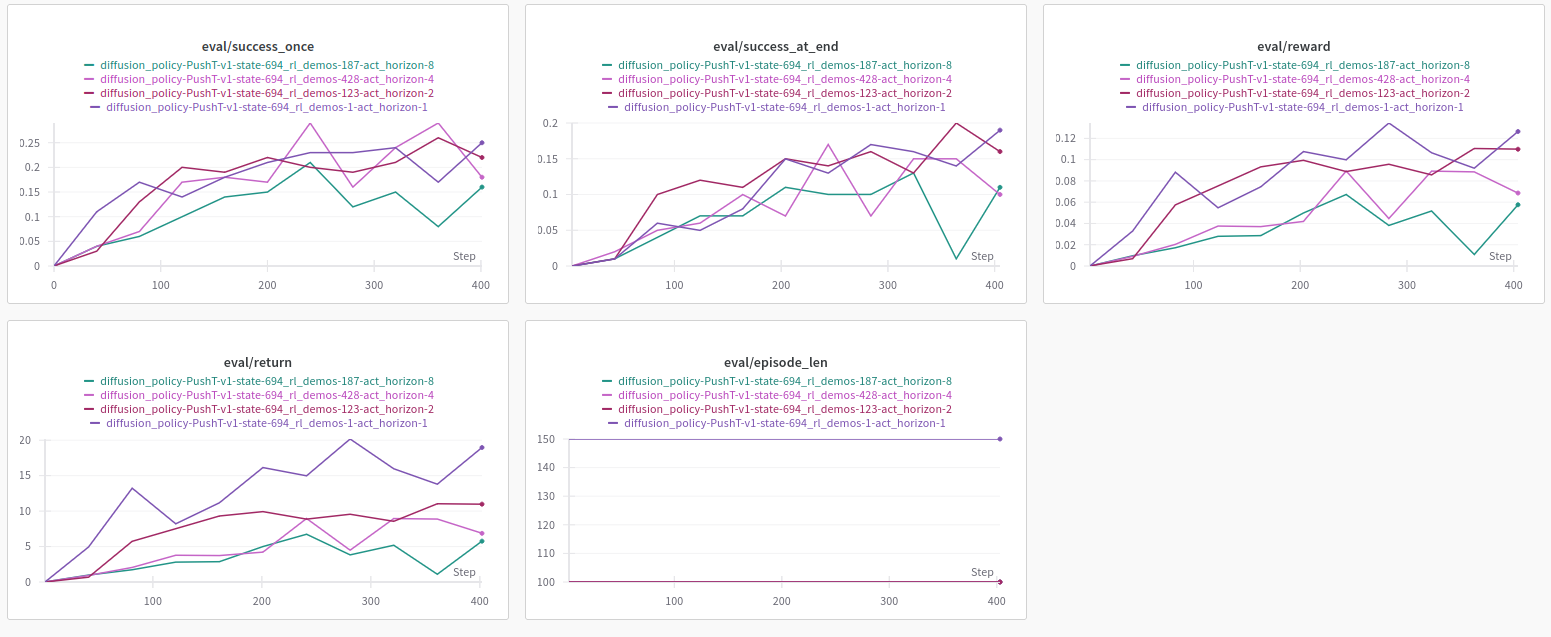

In [7]:
# Visualize MY performance of different Action Horizons. Your performance can be found on wandb
from IPython.display import Image
Image("./media/PushTActionHorizon.png")

In [ ]:
!python train.py --env-id PushT-v1 \
    --demo-path ~/.maniskill/demos/PushT-v1/rl/trajectory.state.pd_ee_delta_pose.physx_cuda.h5 \
    --control-mode "pd_ee_delta_pose" --sim-backend "physx_cuda" --num-demos 694 --max_episode_steps 100 --num_eval_envs 100 \
    --total_iters 50000 --act_horizon 4 --pred_horizon 32 --seed 3 \
    --exp-name diffusion_policy-PushT-v1-state-694-rl_demos-3-pred_horzon-32 --no_capture_video \
    --demo_type=rl --track

python3: can't open file '/content/train.py': [Errno 2] No such file or directory


In [35]:
!python train.py --env-id PushT-v1 \
    --demo-path ~/.maniskill/demos/PushT-v1/rl/trajectory.state.pd_ee_delta_pose.physx_cuda.h5 \
    --control-mode "pd_ee_delta_pose" --sim-backend "physx_cuda" --num-demos 694 --max_episode_steps 100 --num_eval_envs 100 \
    --total_iters 50000 --act_horizon 4 --pred_horizon 8 --seed 631 \
    --exp-name diffusion_policy-PushT-v1-state-694-rl_demos-631-pred_horzon-8 --no_capture_video \
    --demo_type=rl --track

2025-04-30 20:02:21.097752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746043341.416110    9643 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746043341.504271    9643 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-30 20:02:22.174442: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: E

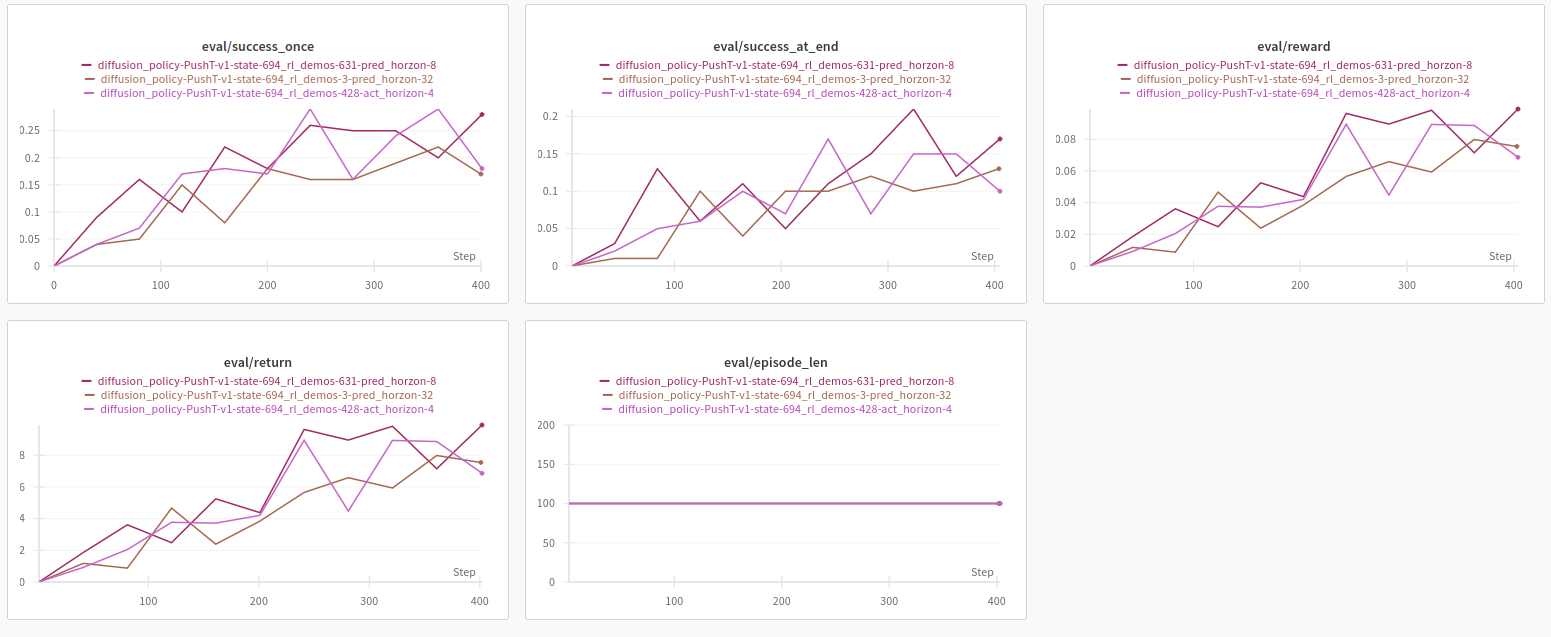

In [8]:
# Visualize MY performance of RGB vs State. Your performance can be found on wandb
from IPython.display import Image
Image("./media/PushTPredictionHorizon.png")

Note that in the above, all runs have an action horizon of 4 (as this seemed to work well for the default prediction horizon of 16). While I could have run more evaluations, the model seemed to work well enough using these hyperparameters, and they were recommended by the repository.

Here's a fun visualization of the robot moving!

In [44]:
# My Output! Real output can be found at /runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations/0.mp4
from IPython.display import HTML
import base64

video_path = './media/RandomSeed136_557.mp4'

# Read video and encode as base64
mp4 = open(video_path, 'rb').read()
data_url = "data:video/mp4;base64," + base64.b64encode(mp4).decode()

# Display video
HTML(f"""
<video width=640 height=480 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

And because you asked, here's a plot of the performance of the different runs

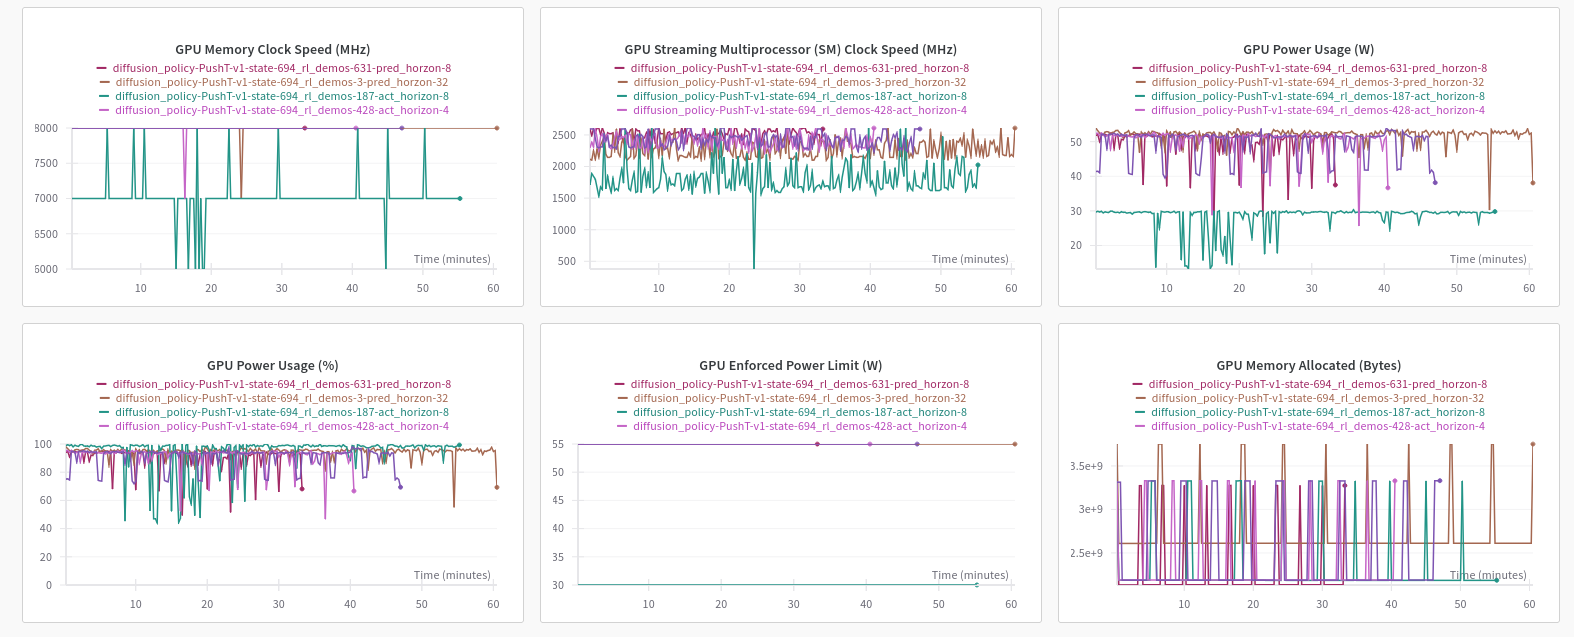

In [43]:
# Visualize MY performance of RGB vs State (not referencing this notebook) Your performance can be found on wandb
from IPython.display import Image
Image("./media/Performance.png")

# T-III Multi Modalities

In [36]:
!python get_initial_state.py

python3: can't open file '/content/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/get_initial_state.py': [Errno 2] No such file or directory


In [37]:
!python visualize.py \
    --checkpoint_path runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/checkpoints/best_eval_success_at_end.pt \
    --output_dir runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations \
    --use_fixed_start_state \
    --initial_state_path pusht_initial_state_pusht_initial_state512.pth \
    --seed 123 \
    --no_video \
    --num_episodes 250 \
    --num_eval_envs 10 \
    --max_episode_steps 100 \
    --act_horizon 4 \

2025-04-30 20:27:50.743334: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746044870.763872   16828 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746044870.770231   16828 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-30 20:27:50.791793: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
╭─ Parsing error ────────────────────────────╮
│ Unrecognized arguments: \                  │
│ ─────────────────────

In [22]:
# My Output! Real output can be found at /runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations/0.mp4
!ls media
from IPython.display import HTML
import base64

video_path = './media/MultiModal136_557.mp4'

# Read video and encode as base64
mp4 = open(video_path, 'rb').read()
data_url = "data:video/mp4;base64," + base64.b64encode(mp4).decode()

# Display video
HTML(f"""
<video width=640 height=480 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

ControlledMultiModal1_111_222.mp4  PushTActionHorizon.png
ControlledMultiModal2_111_222.mp4  PushTPredictionHorizon.png
MultiModal136_557.mp4		   PushTStateVsRGB.png
MultiModal290_111.mp4		   RandomSeed136_557.mp4
MultiModal492_332.mp4		   RandomSeed945_232.mp4


In [26]:
# Visualize MY rollouts using visualize.py (This is a bonus rollout generated )
video_path = './media/ControlledMultiModal1_111_222.mp4'

# Read video and encode as base64
mp4 = open(video_path, 'rb').read()
data_url = "data:video/mp4;base64," + base64.b64encode(mp4).decode()

# Display video
HTML(f"""
<video width=640 height=480 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

Part A: Analysis

Unfortunatley, after having run many rollouts with different initial T positions to try and see whether I could get the diffusion policy to choose an alternate mode such as that depicted in the paper (like going right to circle around the T instead of left), I have as of yet not seen anything that would qualify as an alternate mode. As you can see in the visualizaitons above, the robot only varies slightly from the same course of action in each iteration.

I suspect two root causes for this. Firstly, the policy I'm using is not very good. While the published baseline using similar code to ManiSkill is only supposed to get a success_once accuracy of around 40%-50%, I struggled to break 35% success_once accuracy in all of my trials. Because of the restricted training environment (limited data / compute), and the poor performance, I suspect that multi-modal behaviors have been inhibited by a lack of resources. Secondly, I suspect that despite my best efforts using manual placement, I wasn't able to get the T into a position where the policy had a relatively even choice between two good trajectories. If I had more time, I would view some demonstrations from the training set and try to find two with very similar T and robot arm starting positions to see if I can recreate the choice in the diffusion policy.

# T-IV Steering Techniques

PART A: Literature Review

The area of Steering/Guidance in Diffusion Model Architectures is relatively new, with the two linked papers having been published earlier this year as preliminary / first works in the area. The field is motivated by the existence of large generative models which are trained on large datasets (of varying qualities) which experience distribution shifts when deployed in new settings. While human intervention would ususally exacerbate these shifts, the use of tools to subtly steer these policies in a desired direction has been shown to produce fruitful results. V-GPS does this by training a language-conditioned value function on a large quantity of demonstrations and then using this value function at inference time to select between an array of possible trajectories. This allows humans to steer the policy linguistically. In contrast, ITPS steers the policies by having a human either identify a target location, draw a target trajectory, or physically adjust the robot. The model then integrates this direction via conditioned sampling from the original model's trajectory distribution. Both methods are compatable with a wide array of policies as they do not need to train or update the weights of a generative policy model in any way to steer it. Both methods achieve high performance adapting existing models to new tasks, and ITPS additionally proposes a modified Diffusion architecture which better incorporates their proposed conditioning methods.

PART B:

By manually manipulating the T into the following position, I found a beginning configuration which the policy really struggles with. (See the repos ManiSkill/examples/baselines/diffusion_policy/set_initial_state.py and ManiSkill/examples/baselines/diffusion_policy/visualize.py)

In [29]:
!python set_initial_state.py

python3: can't open file '/content/ManiSkill/examples/baselines/diffusion_policy/ManiSkill/examples/baselines/diffusion_policy/set_initial_state.py': [Errno 2] No such file or directory


In [ ]:
!python visualize.py \
    --checkpoint_path runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/checkpoints/best_eval_success_at_end.pt \
    --output_dir runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations \
    --use_fixed_start_state \
    --initial_state_path pusht_initial_state_.pth \
    --seed 123 \
    --no_video \
    --num_episodes 250 \
    --num_eval_envs 10 \
    --max_episode_steps 100 \
    --act_horizon 4 \

In [38]:
# My Output! Real output can be found at /runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations/0.mp4
video_path = './media/ControlledMultiModal2_111_222.mp4'

mp4 = open(video_path, 'rb').read()
data_url = "data:video/mp4;base64," + base64.b64encode(mp4).decode()

HTML(f"""
<video width=640 height=480 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

PART C:

In [ ]:
!python visualize.py \
    --checkpoint_path runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/checkpoints/best_eval_success_at_end.pt \
    --output_dir runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations \
    --use_fixed_start_state \
    --initial_state_path pusht_initial_state_controlled2.pth \
    --seed 123 \
    --no_video \
    --num_episodes 250 \
    --num_eval_envs 10 \
    --max_episode_steps 100 \
    --act_horizon 4 \

Output:

```
success_once: Mean=0.0000, Std=0.0000 (over 250 episodes)
return: Mean=0.0000, Std=0.0000 (over 250 episodes)
episode_len: Mean=100.0000, Std=0.0000 (over 250 episodes)
reward: Mean=0.0000, Std=0.0000 (over 250 episodes)
success_at_end: Mean=0.0000, Std=0.0000 (over 250 episodes)
```

In [1]:
!python visualize.py \
    --checkpoint_path runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/checkpoints/best_eval_success_at_end.pt \
    --output_dir runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations \
    --use_fixed_start_state \
    --initial_state_path pusht_initial_state_controlled2.pth \
    --seed 234 \
    --no_video \
    --num_episodes 250 \
    --num_eval_envs 10 \
    --max_episode_steps 100 \
    --act_horizon 4 \

python3: can't open file '/content/visualize.py': [Errno 2] No such file or directory


Output:

```
success_once: Mean=0.0000, Std=0.0000 (over 250 episodes)
return: Mean=0.0000, Std=0.0000 (over 250 episodes)
episode_len: Mean=100.0000, Std=0.0000 (over 250 episodes)
reward: Mean=0.0000, Std=0.0000 (over 250 episodes)
success_at_end: Mean=0.0000, Std=0.0000 (over 250 episodes)
```

In [ ]:
!python visualize.py \
    --checkpoint_path runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/checkpoints/best_eval_success_at_end.pt \
    --output_dir runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations \
    --use_fixed_start_state \
    --initial_state_path pusht_initial_state_controlled2.pth \
    --seed 345 \
    --no_video \
    --num_episodes 250 \
    --num_eval_envs 10 \
    --max_episode_steps 100 \
    --act_horizon 4 \

Output:

```
success_once: Mean=0.0040, Std=0.0631 (over 250 episodes)
return: Mean=0.0960, Std=1.5149 (over 250 episodes)
episode_len: Mean=100.0000, Std=0.0000 (over 250 episodes)
reward: Mean=0.0010, Std=0.0151 (over 250 episodes)
success_at_end: Mean=0.0000, Std=0.0000 (over 250 episodes)
```

In [ ]:
!python visualize.py \
    --checkpoint_path runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/checkpoints/best_eval_success_at_end.pt \
    --output_dir runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations \
    --use_fixed_start_state \
    --initial_state_path pusht_initial_state_controlled2.pth \
    --seed 456 \
    --no_video \
    --num_episodes 250 \
    --num_eval_envs 10 \
    --max_episode_steps 100 \
    --act_horizon 4 \

Output:

```
success_once: Mean=0.0000, Std=0.0000 (over 250 episodes)
return: Mean=0.0000, Std=0.0000 (over 250 episodes)
episode_len: Mean=100.0000, Std=0.0000 (over 250 episodes)
reward: Mean=0.0000, Std=0.0000 (over 250 episodes)
success_at_end: Mean=0.0000, Std=0.0000 (over 250 episodes)
```

In [ ]:
!python visualize.py \
    --checkpoint_path runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/checkpoints/best_eval_success_at_end.pt \
    --output_dir runs/diffusion_policy-PushT-v1-state-694_rl_demos-631-pred_horzon-8/visualizations \
    --use_fixed_start_state \
    --initial_state_path pusht_initial_state_controlled2.pth \
    --seed 567 \
    --no_video \
    --num_episodes 250 \
    --num_eval_envs 10 \
    --max_episode_steps 100 \
    --act_horizon 4 \

Output:

```
success_once: Mean=0.0000, Std=0.0000 (over 250 episodes)
return: Mean=0.0000, Std=0.0000 (over 250 episodes)
episode_len: Mean=100.0000, Std=0.0000 (over 250 episodes)
reward: Mean=0.0000, Std=0.0000 (over 250 episodes)
success_at_end: Mean=0.0000, Std=0.0000 (over 250 episodes)
```

Yes, if you're reading this data correctly, this means that across 5 random seeds and 1250 episodes, the policy only succeeded a single time!!!

PART D:

Wow, I've been looking through this for a couple hours and it looks complicated. I've got the repo for V-GPS cloned in recursively as a submodule in my fork of diffusion_policy, but I'm still working on getting its eval script adjusted to use my diffusion_policy and environment. It's possible I'm missing a simple shortcut (such as someone having already implemented something like this in a different repository), but from the direct approach I would expect this to take me about ~1-2 days of hard work. For now I'm going to have to turn in this assessment without this part complete. I'm super interested to see how others implemented this part of the assignment!